## Implementing Gaussian Mixture Models 

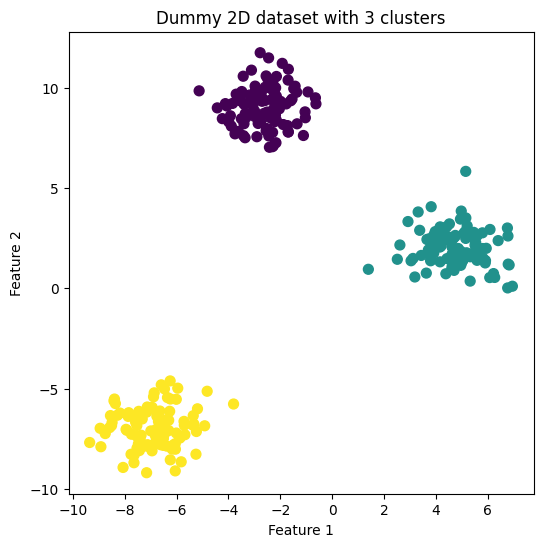

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Create 2D data with 3 clusters
X, y_true = make_blobs(n_samples=300,       # total samples
                       centers=3,          # number of clusters
                       n_features=2,       # 2D
                       cluster_std=1.0,    # standard deviation of clusters
                       random_state=42)    # reproducibility

# Plot the dataset
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y_true, cmap='viridis', s=50)
plt.title("Dummy 2D dataset with 3 clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


#### Sklearns implementation

In [3]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score

Adjusted Rand Index (ARI): 1.000


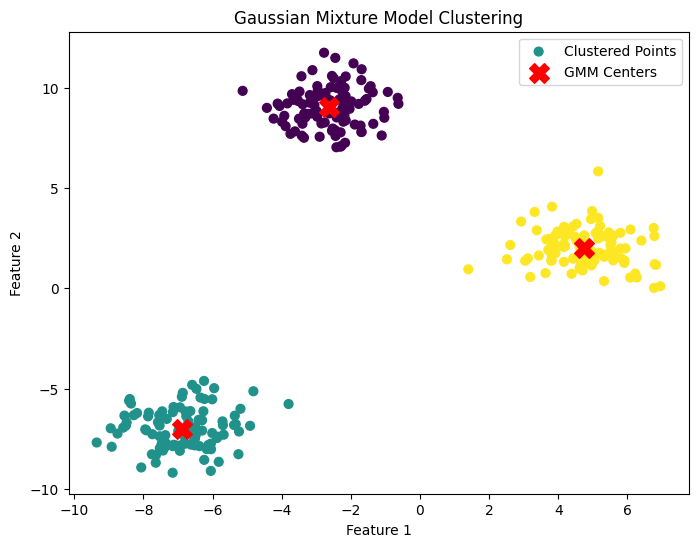

In [4]:

# 2️⃣ Fit Gaussian Mixture Model
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X)

# 3️⃣ Predict cluster labels
y_pred = gmm.predict(X)

# 4️⃣ Evaluate clustering performance
ari = adjusted_rand_score(y_true, y_pred)
print(f"Adjusted Rand Index (ARI): {ari:.3f}")

# 5️⃣ Visualize results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=40, cmap='viridis', label='Clustered Points')

# plot GMM component centers (means)
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], c='red', s=200, marker='X', label='GMM Centers')

plt.title("Gaussian Mixture Model Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [6]:
silhouette = silhouette_score(X, y_pred)
print(f"Silhouette Score: {silhouette:.3f}")


Silhouette Score: 0.848


### Implementation from scratch written by ChatGPT

In [10]:
# We have X, y_true, need y_pred
n_clusters = 3
# initial parameters
pi = np.ones((n_clusters,1))*1/n_clusters
n_examples = X.shape[0]
random_indices = np.random.randint(0, n_examples, size=(3,))
mu = X[random_indices, :]
print(mu)

[[-3.83738367  9.21114736]
 [ 3.37899488  2.89103163]
 [-2.14780202 10.55232269]]


In [16]:
type(mu)

numpy.ndarray

In [17]:
def get_sigma_per_cluster(X, mu):
    '''
    X is 300 X 2; mu is 3 X 2
    '''
    # Step 1: Compute distances manually without np.newaxis
    distances = np.zeros((X.shape[0], mu.shape[0]))
    
    for k in range(mu.shape[0]):
        distances[:, k] = np.sqrt(np.sum((X - mu[k])**2, axis=1))
    
    # Step 2: Assign each point to the closest cluster
    cluster_assignments = np.argmin(distances, axis=1)
    
    # Step 3: Compute std per cluster
    std_per_cluster = np.zeros_like(mu)
    
    for k in range(mu.shape[0]):
        cluster_points = X[cluster_assignments == k]
        if len(cluster_points) > 0:
            std_per_cluster[k] = cluster_points.std(axis=0)
        else:
            std_per_cluster[k] = np.zeros(X.shape[1])  # handle empty cluster
    return std_per_cluster

In [18]:
get_sigma_per_cluster(X, mu)

array([[0.72034537, 0.74065357],
       [5.90507169, 4.59804439],
       [0.68039646, 0.84148469]])

In [34]:
import numpy as np

# ================================
#  GMM from Scratch (Loop version)
# ================================

def gaussian_pdf(x, mu, sigma):
    """
    Compute the multivariate normal PDF value N(x | mu, sigma)
    using loops (no vectorization).
    x, mu are 1D arrays of length d
    sigma is a (d x d) covariance matrix
    """
    d = len(mu)

    # determinant and inverse of covariance
    det = np.linalg.det(sigma)
    inv = np.linalg.inv(sigma)
    if det <= 0:
        det = 1e-12  #
    # normalization constant
    norm_const = 1.0 / (np.power((2 * np.pi), d / 2) * np.sqrt(det))

    # compute exponent manually using loops
    diff = x - mu
    exponent = 0.0
    for i in range(d):
        for j in range(d):
            exponent += diff[i] * inv[i, j] * diff[j]
    exponent = -0.5 * exponent

    return norm_const * np.exp(exponent)


def expectation(X, mu, sigma, pi):
    """E-step: compute responsibilities gamma[i,k]"""
    n_samples = X.shape[0]
    n_clusters = mu.shape[0]
    gamma = np.zeros((n_samples, n_clusters))

    # compute responsibilities
    for i in range(n_samples):
        denom = 0.0
        for k in range(n_clusters):
            gamma[i, k] = pi[k] * gaussian_pdf(X[i], mu[k], sigma[k])
            denom += gamma[i, k]
        # normalize across clusters
        for k in range(n_clusters):
            gamma[i, k] /= (denom + 1e-12)

    return gamma

def initialize_means_kmeanspp(X, n_clusters):
    """Simple k-means++ style init for means."""
    np.random.seed(0)
    n_samples = X.shape[0]
    mu = np.zeros((n_clusters, X.shape[1]))
    mu[0] = X[np.random.randint(0, n_samples)]
    for k in range(1, n_clusters):
        dists = np.array([min([np.linalg.norm(x - c) ** 2 for c in mu[:k]]) for x in X])
        probs = dists / dists.sum()
        idx = np.random.choice(range(n_samples), p=probs)
        mu[k] = X[idx]
    return mu



def maximization(X, gamma, eps=1e-6):
    """M-step: update pi, mu, sigma"""
    n_samples, n_features = X.shape
    n_clusters = gamma.shape[1]

    N_k = np.zeros(n_clusters)
    mu_new = np.zeros((n_clusters, n_features))
    sigma_new = np.zeros((n_clusters, n_features, n_features))
    pi_new = np.zeros((n_clusters, 1))

    for k in range(n_clusters):
        N_k[k] = np.sum(gamma[:, k])
        # update mean
        weighted_sum = np.zeros(n_features)
        for i in range(n_samples):
            weighted_sum += gamma[i, k] * X[i]
        mu_new[k] = weighted_sum / (N_k[k] + 1e-12)

        # update covariance
        cov = np.zeros((n_features, n_features))
        for i in range(n_samples):
            diff = X[i] - mu_new[k]
            cov += gamma[i, k] * np.outer(diff, diff)
            cov += eps * np.eye(n_features)  #
        sigma_new[k] = cov / (N_k[k] + 1e-12)

        # update mixing coefficient
        pi_new[k] = N_k[k] / n_samples

    return pi_new, mu_new, sigma_new


def log_likelihood(X, mu, sigma, pi):
    """Compute total log-likelihood"""
    n_samples = X.shape[0]
    n_clusters = mu.shape[0]
    log_l = 0.0
    for i in range(n_samples):
        prob = 0.0
        for k in range(n_clusters):
            prob += pi[k] * gaussian_pdf(X[i], mu[k], sigma[k])
        log_l += np.log(prob + 1e-12)
    return log_l


# ===============================
#        MAIN EM LOOP
# ===============================

def gmm_em(X, n_clusters=3, max_iter=200, tol=1e-4):
    n_samples, n_features = X.shape

    # ---- Initialization ----
    np.random.seed(4)
    # random_indices = np.random.randint(0, n_samples, size=n_clusters)
    mu = initialize_means_kmeanspp(X, n_clusters)
    # mu = X[random_indices, :]
    sigma = np.array([np.eye(n_features) for _ in range(n_clusters)])
    pi = np.ones((n_clusters, 1)) / n_clusters

    prev_log_l = None

    for iteration in range(max_iter):
        # E-step
        gamma = expectation(X, mu, sigma, pi)

        # M-step
        pi, mu, sigma = maximization(X, gamma)

        # log-likelihood check
        current_log_l = log_likelihood(X, mu, sigma, pi)
        if prev_log_l is not None and abs(current_log_l - prev_log_l) < tol:
            print(f"Converged at iteration {iteration}")
            break
        prev_log_l = current_log_l

    # final predictions (cluster = argmax responsibility)
    y_pred = np.argmax(gamma, axis=1)

    return y_pred, mu, sigma, pi




/tmp/ipykernel_1396/1860943485.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i, k] = pi[k] * gaussian_pdf(X[i], mu[k], sigma[k])


Converged at iteration 1

Final cluster means:
 [[ 4.74710337  2.01059427]
 [-6.88387179 -6.98398415]
 [-2.63323268  9.04356978]]

Final mixture weights:
 [0.33333333 0.33333333 0.33333333]


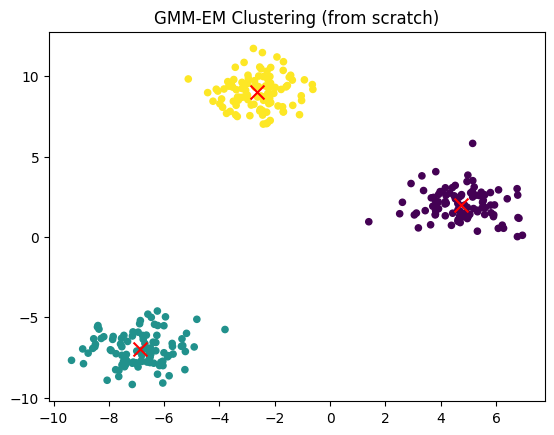

In [35]:
# Example: generate dummy data for testing
# ===============================
#  Example usage
# ===============================
# Suppose you already have X (n_samples x 2)
y_pred, mu, sigma, pi = gmm_em(X, n_clusters=3)

print("\nFinal cluster means:\n", mu)
print("\nFinal mixture weights:\n", pi.ravel())

    # Optional: compare with true labels visually
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=20)
plt.scatter(mu[:, 0], mu[:, 1], c='red', s=100, marker='x')
plt.title("GMM-EM Clustering (from scratch)")
plt.show()

In [36]:
silhouette = silhouette_score(X, y_pred)
print(f"Silhouette Score: {silhouette:.3f}")


Silhouette Score: 0.848
